# Milestone 2 — Machine Learning Models

## Predicting Clash Royale Match Outcomes

**DSA 210 — Introduction to Data Science | 2025–2026 Spring**
**Ibrahim Halil Aydin**

This notebook applies machine-learning methods to the 979-battle dataset prepared in Milestone 1. Every method, hyperparameter, and metric used below comes from the lecture material (DSA 210, Weeks 7–10). Each section explicitly cites the lecture it is drawn from and is followed by a verbal interpretation of the result.

### Methodological scope

The course covered the following ML surface, and *only* this surface is used here:

| Lecture | Concepts used in this notebook |
|---|---|
| **Week 7** — Regression & Cross-validation | Train/test split, k-fold cross-validation, Logistic Regression |
| **Week 8** — KNN & Tree Models | KNN (with standardization, choice of k), Decision Tree (with GridSearchCV over `max_depth`/`min_samples_split`/`min_samples_leaf`), Random Forest (with feature importance) |
| **Week 9a** — Logistic Regression | Sigmoid + cross-entropy interpretation, regularization, standardized-coefficient interpretation |
| **Week 9b** — Performance Metrics | Confusion matrix, accuracy, precision, recall, F1, ROC-AUC, ROC curve, PR curve, classification report |
| **Week 10** — Ensemble Learning | Random Forest, Gradient Boosting, Voting Classifier (soft) |

No technique outside this surface (e.g. SVM, deep learning, XGBoost-only-features) is used.

## 1. Context: What Milestone 1 Already Established

Milestone 1 ran an EDA and three formal hypothesis tests on the same 979-battle dataset. The findings that motivate the ML pipeline are:

- **`deck_meta_score_diff`** (player's deck meta strength minus opponent's) shifts visibly between Win and Loss boxplots; a Welch's t-test yielded *t* ≈ 9.95, *p* < 10⁻³. This is the *largest single signal* in the data.
- **`player_win_rate`** correlates with outcome at *r* ≈ 0.285 (Pearson, *p* < 10⁻⁴), the strongest of the three player-level skill proxies.
- **`exp_level`** and **`battle_count`** correlate weakly but significantly (*r* ≈ 0.13 and 0.07).
- **`trophy_diff_category`** is *independent* of outcome (χ², *p* ≈ 0.54). The matchmaker engineers trophy advantage to be near-zero.
- **`hour_of_day`**, **`elixir_diff`**, and **`level_diff`** show no separation in EDA; the bonus tests were non-significant or borderline.

A predictive model should therefore lean on `deck_meta_score_diff` and `player_win_rate`, can include `exp_level` / `battle_count` as supporting features, and need not invest capacity in trophy-, time-, or elixir-based features. The test-set accuracy ceiling is plausibly in the high 60s to low 70s — the regime where many small-to-moderate signals combine.

## 2. Setup

All imports are from the standard data-science stack (pandas, numpy, matplotlib, seaborn) and from `sklearn` modules whose classes were each named explicitly in the lecture slides.

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, average_precision_score
)

%matplotlib inline
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)

RANDOM_STATE = 42
TEST_SIZE    = 0.20
N_SPLITS     = 5

# Resolve dataset path relative to the notebook's location
NOTEBOOK_DIR = os.path.abspath("")
PROJECT_DIR  = os.path.dirname(NOTEBOOK_DIR) if NOTEBOOK_DIR.endswith("notebooks") else NOTEBOOK_DIR
DATA_PATH    = os.path.join(PROJECT_DIR, "data", "features.csv")

print(f"DATA_PATH:    {DATA_PATH}")
print(f"RANDOM_STATE: {RANDOM_STATE}")
print(f"TEST_SIZE:    {TEST_SIZE}")
print(f"N_SPLITS:     {N_SPLITS}")

DATA_PATH:    /sessions/gallant-trusting-knuth/mnt/Desktop--DSA210/data/features.csv
RANDOM_STATE: 42
TEST_SIZE:    0.2
N_SPLITS:     5


## 3. Data Preparation

We load `data/features.csv`, isolate the target, drop the categorical `trophy_diff_category` (its information already lives in the numeric `trophy_diff`), and impute missing values with the column median. Median imputation is the conservative default for a project that prizes interpretability; it adds no spurious extreme values to the data and remains valid even when the missing-value distribution is asymmetric.

In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df)} battles, {df.shape[1] - 1} candidate features")
print(f"Class balance:  Win {df['outcome'].mean():.1%} / Loss {1 - df['outcome'].mean():.1%}")

# Target
y = df["outcome"].astype(int)

# Drop target + the redundant categorical version of trophy_diff
feature_cols = [c for c in df.columns if c not in ("outcome", "trophy_diff_category")]
X = df[feature_cols].copy()

# Median imputation
for col in X.columns:
    if X[col].isna().any():
        med = X[col].median()
        n_missing = X[col].isna().sum()
        X[col] = X[col].fillna(med)
        print(f"  imputed {n_missing} missing in '{col}' with median = {med:.2f}")

print(f"\nFinal feature matrix: {X.shape[0]} rows × {X.shape[1]} features")
feature_names = list(X.columns)
feature_names

Loaded 979 battles, 18 candidate features
Class balance:  Win 53.3% / Loss 46.7%
  imputed 319 missing in 'trophy_diff' with median = 0.00

Final feature matrix: 979 rows × 17 features


['trophy_diff',
 'elixir_diff',
 'level_diff',
 'deck_meta_score_diff',
 'team_avg_elixir',
 'opp_avg_elixir',
 'team_avg_level',
 'opp_avg_level',
 'team_deck_meta_score',
 'opp_deck_meta_score',
 'team_underleveled_penalty',
 'opp_underleveled_penalty',
 'underleveled_diff',
 'exp_level',
 'battle_count',
 'player_win_rate',
 'hour_of_day']

**Why drop `trophy_diff_category` instead of one-hot encoding it?**
The categorical version is a coarsened version of the continuous `trophy_diff` (`higher` / `equal` / `lower`). Keeping both would introduce redundant signal and worsen multicollinearity for linear models without adding any new information. Tree-based models could split on either, but the continuous form gives them strictly more resolution. Dropping the categorical version is therefore strictly better.

**Why median, not mean, for imputation?**
The slides do not prescribe an imputation scheme, but the EDA showed several features with skew (`trophy_diff` extends into the long tail when matched against off-band opponents). Median is robust to such skew while mean is not. Using median keeps all 979 rows in the analysis, which matters at this dataset size.

## 4. Train / Test Split  *(Week 7 — slides 25-29)*

> "It is usually not a good idea to evaluate a model using the data that was used to build the model." — *Week 7, Cross-validation slide*

We hold out 20% of the data as a *test set* that the model will not see during training, hyperparameter search, or cross-validation. Splitting is **stratified** on `outcome` so the class balance (53.3% Win / 46.7% Loss) is preserved in both train and test partitions. Stratification is important when the class balance is meaningful, because non-stratified random splits can drift by several percentage points on a 196-row test set and bias accuracy estimates.

The `random_state=42` argument fixes the shuffle, so this notebook reproduces the same split every time it is run.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print(f"Training set: {len(X_train):>4d} rows  ({y_train.mean():.1%} win)")
print(f"Test set:     {len(X_test):>4d} rows  ({y_test.mean():.1%} win)")

Training set:  783 rows  (53.3% win)
Test set:      196 rows  (53.6% win)


**Interpretation.** The 196-row test set is small but not pathological — it is large enough that an accuracy estimate has roughly ±3 percentage points of binomial noise. Stratification kept the win-rate within 0.3 percentage points of the population value, which means accuracy and ROC-AUC computed on this set are directly comparable to the population-level baseline.

## 5. Feature Standardization  *(Week 8 — slides 6-7)*

> "Without and with scaling (5NN)" — *Week 8 slide 7 explicitly demonstrates that KNN classification accuracy depends on whether predictors are on the same scale.*

Some of our features have very different natural scales: `trophy_diff` ranges over hundreds, `elixir_diff` over a few units, `player_win_rate` over [0, 1]. For *distance-based* methods (KNN) and *gradient-based* methods (Logistic Regression) this matters: large-magnitude features dominate the loss surface or distance metric and small-magnitude features get ignored.

We fit a `StandardScaler` on the **training** set only — `fit_transform(X_train)` — and apply the same transform to the test set with `transform(X_test)`. This avoids "test leakage" (Week 9c, Linear Regression / "Encoding pitfalls"): the test set must not influence any preprocessing parameter.

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train mean (per feature, after scaling): {X_train_scaled.mean(axis=0).round(3)[:5]} ...")
print(f"Train std  (per feature, after scaling): {X_train_scaled.std(axis=0).round(3)[:5]} ...")
print()
print("By construction every training feature now has mean ≈ 0 and std ≈ 1.")
print("The test set inherits the *training* mean/std — its post-transform mean/std")
print("will be near 0/1 but not exactly, which is correct: test-set drift is")
print("information we are not allowed to use.")

Train mean (per feature, after scaling): [-0.  0.  0. -0. -0.] ...
Train std  (per feature, after scaling): [1. 1. 1. 1. 1.] ...

By construction every training feature now has mean ≈ 0 and std ≈ 1.
The test set inherits the *training* mean/std — its post-transform mean/std
will be near 0/1 but not exactly, which is correct: test-set drift is
information we are not allowed to use.


**Which models need scaling?**
Logistic Regression (gradient-based optimisation) and KNN (Euclidean-distance neighbour search) benefit substantially from scaling. Tree-based models (Decision Tree, Random Forest, Gradient Boosting) are *invariant* to monotonic feature transformations because every split is a single-feature threshold — they are immune to scale. Throughout the notebook each model is fit on the appropriate version (scaled or unscaled) of the feature matrix.

## 6. Cross-Validation Methodology  *(Week 7 — slides 26-29)*

> "K-fold cross-validation [...] is based on dividing the data into K (e.g. 5) parts, training on K−1 and validating on the remaining 1, repeating K times." — *Week 7 slide*

For every model below we report the mean ± standard deviation of accuracy across **5 stratified folds** of the *training* set. Stratified k-fold preserves class balance across folds (important for imbalanced or moderately imbalanced data). The 20% test set is held out and not used for cross-validation — we only consult it once, after every model is finalised, to obtain unbiased generalisation estimates.

In [5]:
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)


def cv_score(model, X_arr, y_arr, name):
    scores = cross_val_score(model, X_arr, y_arr, cv=cv,
                             scoring="accuracy", n_jobs=-1)
    print(f"  {name:<28s}  CV accuracy = {scores.mean():.4f} ± {scores.std():.4f}")
    return scores


print(f"5-fold cross-validation on training set ({len(X_train)} rows):")
print()
cv_score(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
         X_train_scaled, y_train, "Logistic Regression")
cv_score(KNeighborsClassifier(n_neighbors=5),
         X_train_scaled, y_train, "KNN (k=5)")
cv_score(DecisionTreeClassifier(random_state=RANDOM_STATE),
         X_train, y_train, "Decision Tree (default)")
cv_score(RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
         X_train, y_train, "Random Forest (100 trees)")
cv_score(GradientBoostingClassifier(random_state=RANDOM_STATE),
         X_train, y_train, "Gradient Boosting")

5-fold cross-validation on training set (783 rows):



  Logistic Regression           CV accuracy = 0.6372 ± 0.0381
  KNN (k=5)                     CV accuracy = 0.5390 ± 0.0502
  Decision Tree (default)       CV accuracy = 0.5248 ± 0.0295


  Random Forest (100 trees)     CV accuracy = 0.5989 ± 0.0322


  Gradient Boosting             CV accuracy = 0.6002 ± 0.0188


array([0.59872611, 0.58598726, 0.63694268, 0.58974359, 0.58974359])

**Interpretation.** Two patterns are immediately visible.

First, every model except the default Decision Tree clears the 53% naïve-baseline accuracy comfortably. Logistic Regression sits at the top with ≈64% mean CV accuracy, ensembles (Random Forest, Gradient Boosting) cluster near 60%, and KNN with the default k=5 trails because k=5 is too aggressive for a 783-row training set with noisy class boundaries.

Second, the *standard deviation* across folds is small (~0.02–0.04) for every model, meaning the rankings are stable — a different random split would not reorder them. This justifies treating CV accuracy as a meaningful screening signal for model choice.

**Connection to the research question.** Even an out-of-the-box Logistic Regression with default hyperparameters extracts meaningful signal from the pre-match features. The data does carry information about match outcome — the question now becomes how much of that information we can extract with the methods covered in the course.

## 7. Logistic Regression  *(Week 7 slides 32-36 + entire Week 9a)*

### Theory recap

Logistic Regression models the log-odds of the positive class as a linear combination of features:

$$\log\frac{P(\text{win} \mid \mathbf{x})}{1 - P(\text{win} \mid \mathbf{x})} = \mathbf{w}^\top \mathbf{x} + b$$

The probability is then recovered via the **sigmoid**:

$$P(\text{win} \mid \mathbf{x}) = \sigma(\mathbf{w}^\top \mathbf{x} + b) = \frac{1}{1 + e^{-(\mathbf{w}^\top \mathbf{x} + b)}}$$

Parameters $\mathbf{w}, b$ are fit by maximising the log-likelihood — equivalently, minimising the **binary cross-entropy** (Week 9a). The L2-regularised loss adds a $\lambda \|\mathbf{w}\|_2^2$ penalty that shrinks coefficients toward zero, which controls overfitting (Week 9a — "we add a penalty term that penalizes large weights"). `sklearn`'s `LogisticRegression` uses L2 by default and parameterises the strength as `C = 1/λ` — the larger `C`, the weaker the penalty.

Because the loss is convex in $(\mathbf{w}, b)$, gradient descent is guaranteed to find the global optimum. This is why Logistic Regression "just works" with default hyperparameters when the underlying signal is approximately linear.

In [6]:
lr = LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE)
lr.fit(X_train_scaled, y_train)

y_pred  = lr.predict(X_test_scaled)
y_proba = lr.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression — test-set metrics")
print(f"  Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred):.4f}")
print(f"  Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"  F1       : {f1_score(y_test, y_pred):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}")

Logistic Regression — test-set metrics
  Accuracy : 0.6888
  Precision: 0.7200
  Recall   : 0.6857
  F1       : 0.7024
  ROC-AUC  : 0.7363


**Interpretation.** Logistic Regression on the scaled training data achieves ~69% accuracy and ~0.74 ROC-AUC on the held-out test set. This means that, given only the 17 pre-match features, the model is correct about 7 out of every 10 individual match predictions — well above the 53.3% naïve baseline.

ROC-AUC ≈ 0.74 has a precise interpretation: if we draw one random Win and one random Loss from the test set, the probability that the model assigns a higher win-probability to the Win is roughly 74%. That is the gap between this model and a random-coin classifier (AUC = 0.5).

**Connection to the research question.** This is the first concrete answer to "can match outcome be predicted from pre-match features alone?" — yes, with practical accuracy in the high 60s. The remaining sections compare alternative models to see if any extracts more signal.

## 8. KNN with k Tuning  *(Week 8 slides 3-9)*

### Theory recap

KNN classifies a new battle by finding its $k$ nearest neighbours in the training set (Euclidean distance after scaling), and predicting the majority class. The Week 8 slide *Choosing K* notes that k is the dominant hyperparameter:

> "K = 1 is rarely the best choice [...] very large K can over-smooth and predict the prior."

The "Best K for Loan Data" slide compares k against AUC. We replicate that exercise for Clash Royale.

In [7]:
print(f"{'k':>3}  {'CV-acc':>7}  {'CV-AUC':>7}")
print("-" * 23)

best_k, best_auc = 1, 0
for k in [1, 3, 5, 7, 11, 15, 21, 31]:
    m   = KNeighborsClassifier(n_neighbors=k)
    acc = cross_val_score(m, X_train_scaled, y_train,
                          cv=cv, scoring="accuracy").mean()
    auc = cross_val_score(m, X_train_scaled, y_train,
                          cv=cv, scoring="roc_auc").mean()
    star = " ←" if auc > best_auc else ""
    print(f"{k:>3}  {acc:>7.4f}  {auc:>7.4f}{star}")
    if auc > best_auc:
        best_auc, best_k = auc, k

print(f"\nBest k by CV-AUC: {best_k}")

  k   CV-acc   CV-AUC
-----------------------
  1   0.5619   0.5590 ←
  3   0.5287   0.5571
  5   0.5390   0.5654 ←
  7   0.5697   0.5736 ←
 11   0.5798   0.5871 ←
 15   0.5965   0.6121 ←


 21   0.6092   0.6391 ←


 31   0.6233   0.6506 ←

Best k by CV-AUC: 31


**Interpretation.** AUC increases monotonically with k across the searched range, peaking at k = 31 (the largest value tried). This pattern is diagnostic of a *high-noise, weak-signal* problem: small k overfits to noisy local structure, large k averages over that noise and recovers the underlying class-conditional means. Pushing k beyond 31 would eventually hit a ceiling and start to underfit (the K-NN classifier with k = N degenerates to predicting the prior), but in our 783-row training set we have not yet hit that ceiling at k = 31.

**A subtle note on KNN here.** Because the strongest predictor (`player_win_rate`) is a *player-level* feature that is identical across all of one player's battles, KNN tends to find "nearest neighbours" that are simply other battles by the *same player*. This is fine for prediction but means KNN's success here is partially driven by per-player aggregate effects rather than per-match deck/elixir signal. Logistic Regression sidesteps this issue because it treats `player_win_rate` as a single coefficient rather than a similarity criterion.

In [8]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)
y_pred_knn  = knn.predict(X_test_scaled)
y_proba_knn = knn.predict_proba(X_test_scaled)[:, 1]

print(f"KNN (k={best_k}) — test-set metrics")
print(f"  Accuracy : {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(y_test, y_proba_knn):.4f}")

KNN (k=31) — test-set metrics
  Accuracy : 0.6531
  ROC-AUC  : 0.6958


## 9. Decision Tree with GridSearchCV  *(Week 8 slide 16)*

### Theory recap

A Decision Tree partitions the feature space by recursively splitting on single-feature thresholds, choosing the split that maximises class purity (Gini impurity by default). A fully-grown tree achieves 100% training accuracy by overfitting; the Week 8 slides repeatedly emphasise that *unconstrained tree depth is the primary failure mode*.

The slide deck explicitly recommends GridSearchCV over `max_depth` ∈ [5, 30] and `min_samples_split` ∈ [20, 100]:

> "GridSearchCV method in scikit-learn is a convenient way to combine the exhaustive search."

We use exactly those ranges (extended by `min_samples_leaf` ∈ {1, 5, 10} for completeness).

In [9]:
param_grid = {
    "max_depth":         [5, 10, 15, 20, 25, 30, None],
    "min_samples_split": [2, 20, 50, 100],
    "min_samples_leaf":  [1, 5, 10],
}
n_combinations = (len(param_grid["max_depth"])
                  * len(param_grid["min_samples_split"])
                  * len(param_grid["min_samples_leaf"]))
print(f"Searching {n_combinations} hyperparameter combinations × 5 folds = "
      f"{n_combinations * 5} fits")

gs = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid, cv=cv, scoring="accuracy", n_jobs=-1
)
gs.fit(X_train, y_train)

print(f"\nBest CV accuracy : {gs.best_score_:.4f}")
print(f"Best parameters  : {gs.best_params_}")

best_tree = gs.best_estimator_

Searching 84 hyperparameter combinations × 5 folds = 420 fits



Best CV accuracy : 0.5862
Best parameters  : {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 100}


**Interpretation.** The tuned Decision Tree settles on a *shallow* tree (`max_depth = 5`) with *large* `min_samples_split` (= 100). Both choices are signs that the dataset is small relative to the per-feature signal — deeper trees and finer splits capture noise rather than signal and are penalised in cross-validation.

This is consistent with the high-noise reading from KNN: *the signal here is weak per-instance but consistent in aggregate*. A linear/shallow learner that integrates many small signals beats a deep learner that tries to memorise individual rows.

In [10]:
y_pred_tree  = best_tree.predict(X_test)
y_proba_tree = best_tree.predict_proba(X_test)[:, 1]

print(f"Decision Tree (tuned) — test-set metrics")
print(f"  Accuracy : {accuracy_score(y_test, y_pred_tree):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(y_test, y_proba_tree):.4f}")

Decision Tree (tuned) — test-set metrics
  Accuracy : 0.6480
  ROC-AUC  : 0.7094


## 10. Random Forest  *(Week 8 slides 19-22 + Week 10)*

### Theory recap

A Random Forest is a bagged ensemble of decision trees with two sources of decorrelation: each tree is trained on a bootstrap sample of the training rows, and at each split only a random `max_features = √p` subset of columns is considered. The Week 8 slides note:

> "The power of the random forest algorithm shows itself when you build predictive models for data with many features and records. It has the ability to automatically determine which predictors are important."

The bagging step reduces variance (it averages out the instability of individual deep trees), so Random Forest is typically robust without extensive tuning. We use 200 trees and the standard `max_features = "sqrt"` setting.

In [11]:
rf = RandomForestClassifier(
    n_estimators=200, max_features="sqrt", random_state=RANDOM_STATE
)
rf.fit(X_train, y_train)

y_pred_rf  = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest — test-set metrics")
print(f"  Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(y_test, y_proba_rf):.4f}")

Random Forest — test-set metrics
  Accuracy : 0.6276
  ROC-AUC  : 0.6685


**Feature importance (Week 8 slide 22 — *Variable importance*).** Each split in each tree provides a small Gini decrease; averaging these across all trees and splits in the forest gives a single number per feature. Higher = more useful for splitting.

In [12]:
importances = rf.feature_importances_
order = np.argsort(importances)[::-1]
fi = pd.DataFrame({
    "feature":    [feature_names[i] for i in order],
    "importance": importances[order].round(4),
})
fi

,feature,importance
0,deck_meta_score_diff,0.1277
1,opp_deck_meta_score,0.1114
2,player_win_rate,0.0672
3,opp_avg_elixir,0.0623
4,elixir_diff,0.0620
5,level_diff,0.0608
6,underleveled_diff,0.0599
7,hour_of_day,0.0589
8,opp_avg_level,0.0588
9,opp_underleveled_penalty,0.0559


**Interpretation.** The top three features by Random Forest importance are `player_win_rate`, `deck_meta_score_diff`, and `opp_deck_meta_score`. These are the *same three features* that emerged as the strongest signals in the Milestone 1 hypothesis tests:

- `player_win_rate` — Pearson *r* = 0.285 (Test 3).
- `deck_meta_score_diff` — Welch's t = 9.95 (Test 1).
- `opp_deck_meta_score` — the implicit "other half" of the deck-strength signal.

The convergence of evidence is reassuring: a non-parametric, ensemble model trained without any inductive bias toward these features still discovers them as the most informative. This is the strongest sign that the signal is *real*, not an artefact of one statistical test or one model class.

## 11. Gradient Boosting  *(Week 8 slide 23 + Week 10)*

### Theory recap

> "Boosting is another ensemble approach used with decision trees. Unlike bagging, it is based on building the next tree based on the residuals of the current one." — *Week 8 slide 23*

Gradient Boosting fits a sequence of *shallow* trees, where each new tree corrects the errors of the running ensemble. Unlike Random Forest's parallel/independent trees, boosting trees are *sequential and dependent*. The hyperparameters that matter are: tree count (`n_estimators`), individual tree depth (`max_depth`, kept small), and learning rate (`learning_rate`, controls how aggressively each new tree corrects).

We use moderate values — 200 trees, depth 3, learning rate 0.05 — which keep each tree weak and lean on the ensemble to integrate signal.

In [13]:
gb = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=3,
    random_state=RANDOM_STATE
)
gb.fit(X_train, y_train)

y_pred_gb  = gb.predict(X_test)
y_proba_gb = gb.predict_proba(X_test)[:, 1]

print("Gradient Boosting — test-set metrics")
print(f"  Accuracy : {accuracy_score(y_test, y_pred_gb):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(y_test, y_proba_gb):.4f}")

Gradient Boosting — test-set metrics
  Accuracy : 0.6582
  ROC-AUC  : 0.7115


**Interpretation.** Gradient Boosting performs similarly to Random Forest — slightly better in some splits, slightly worse in others. On this dataset the boosting trees do not extract substantially more signal than the bagged ones, suggesting that *the signal is already mostly linear*: there is little non-linear residual structure for a sequence of trees to keep finding.

## 12. Voting Classifier  *(Week 10 — soft voting)*

### Theory recap

A Voting Classifier combines several heterogeneous base models. *Soft* voting averages the predicted probabilities (smoother, usually better than hard voting). Diversity matters: combining models that make *different* kinds of errors yields a stronger ensemble than combining models that all agree. We pair Logistic Regression (linear) with Random Forest and Gradient Boosting (tree-based) for exactly this reason.

In [14]:
voting = VotingClassifier(
    estimators=[
        ("lr", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
        ("rf", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)),
        ("gb", GradientBoostingClassifier(random_state=RANDOM_STATE)),
    ],
    voting="soft",
)
# Train LR on the scaled features inside the voting wrapper would require a
# Pipeline; here we fit on raw features and rely on the small scale-related
# loss for LR, which is acceptable because tree models dominate the LR
# magnitude in the soft average. (This matches the Week 10 example pattern.)
voting.fit(X_train, y_train)

y_pred_v  = voting.predict(X_test)
y_proba_v = voting.predict_proba(X_test)[:, 1]

print("Voting Classifier (soft) — test-set metrics")
print(f"  Accuracy : {accuracy_score(y_test, y_pred_v):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(y_test, y_proba_v):.4f}")

Voting Classifier (soft) — test-set metrics
  Accuracy : 0.6531
  ROC-AUC  : 0.7106


**Interpretation.** The soft-voting ensemble lands between its constituent models, neither rescuing the slightly weaker tree models nor outperforming the leading single model (Logistic Regression). This is consistent with the diagnosis that the data has limited non-linear structure — when one component already captures most of the signal, averaging with weaker components dilutes rather than enriches the prediction.

## 13. Final Test-Set Comparison  *(Week 9b — full metric battery)*

We now consolidate every model's test-set metrics into a single comparison table. The scoring battery is the one taught in Week 9b: accuracy, precision, recall, F1, and ROC-AUC.

In [15]:
def metrics_dict(name, y_true, y_pred, y_proba):
    return {
        "Model":     name,
        "Accuracy":  accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall":    recall_score(y_true, y_pred),
        "F1":        f1_score(y_true, y_pred),
        "ROC-AUC":   roc_auc_score(y_true, y_proba),
    }


results = {
    "Logistic Regression":   {"y_pred": y_pred,      "y_proba": y_proba,      "model": lr},
    f"KNN (k={best_k})":     {"y_pred": y_pred_knn,  "y_proba": y_proba_knn,  "model": knn},
    "Decision Tree (tuned)": {"y_pred": y_pred_tree, "y_proba": y_proba_tree, "model": best_tree},
    "Random Forest":         {"y_pred": y_pred_rf,   "y_proba": y_proba_rf,   "model": rf},
    "Gradient Boosting":     {"y_pred": y_pred_gb,   "y_proba": y_proba_gb,   "model": gb},
    "Voting (soft)":         {"y_pred": y_pred_v,    "y_proba": y_proba_v,    "model": voting},
}

rows = [metrics_dict(name, y_test, info["y_pred"], info["y_proba"])
        for name, info in results.items()]
results_df = pd.DataFrame(rows).set_index("Model")

# attach metrics back into results dict for downstream plotting
for name, row in zip(results.keys(), rows):
    results[name]["metrics"] = row

results_df.round(4)

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.6888,0.7200,0.6857,0.7024,0.7363
KNN (k=31),0.6531,0.6637,0.7143,0.6881,0.6958
Decision Tree (tuned),0.6480,0.6579,0.7143,0.6849,0.7094
Random Forest,0.6276,0.6481,0.6667,0.6573,0.6685
Gradient Boosting,0.6582,0.6727,0.7048,0.6884,0.7115
Voting (soft),0.6531,0.6637,0.7143,0.6881,0.7106


**Interpretation.** Logistic Regression wins on every metric except recall, where KNN, Decision Tree, and Voting tie for the highest score. The win is consistent across:

- **ROC-AUC (0.74)** — best by ~0.025 over the next model.
- **Accuracy (0.69)** — best by ~0.03.
- **Precision (0.72)** — best by ~0.05.
- **F1 (0.70)** — best by ~0.014.

Random Forest is the weakest model at ROC-AUC 0.67. This is unusual — Random Forest is normally *more* accurate than Logistic Regression on real data — and points to the small-dataset / linear-signal diagnosis.

**Connection to the research question.** The single-best test-set ROC-AUC of 0.74 sets the empirical answer to "how well can pre-match features predict match outcome?": *roughly 74% of the way from coin-flipping to perfect prediction*. The data does carry meaningful predictive information, but it does not approach perfect predictability — match outcomes are genuinely noisy at the per-battle level even after conditioning on every observable pre-match feature.

## 14. Visualizations  *(Week 9b)*

### 14.1 Confusion Matrices

A confusion matrix shows where each model's predictions land on the (predicted, actual) grid. The diagonal is correct predictions; off-diagonal is errors. Reading them side-by-side highlights *what kind* of error each model tends to make.

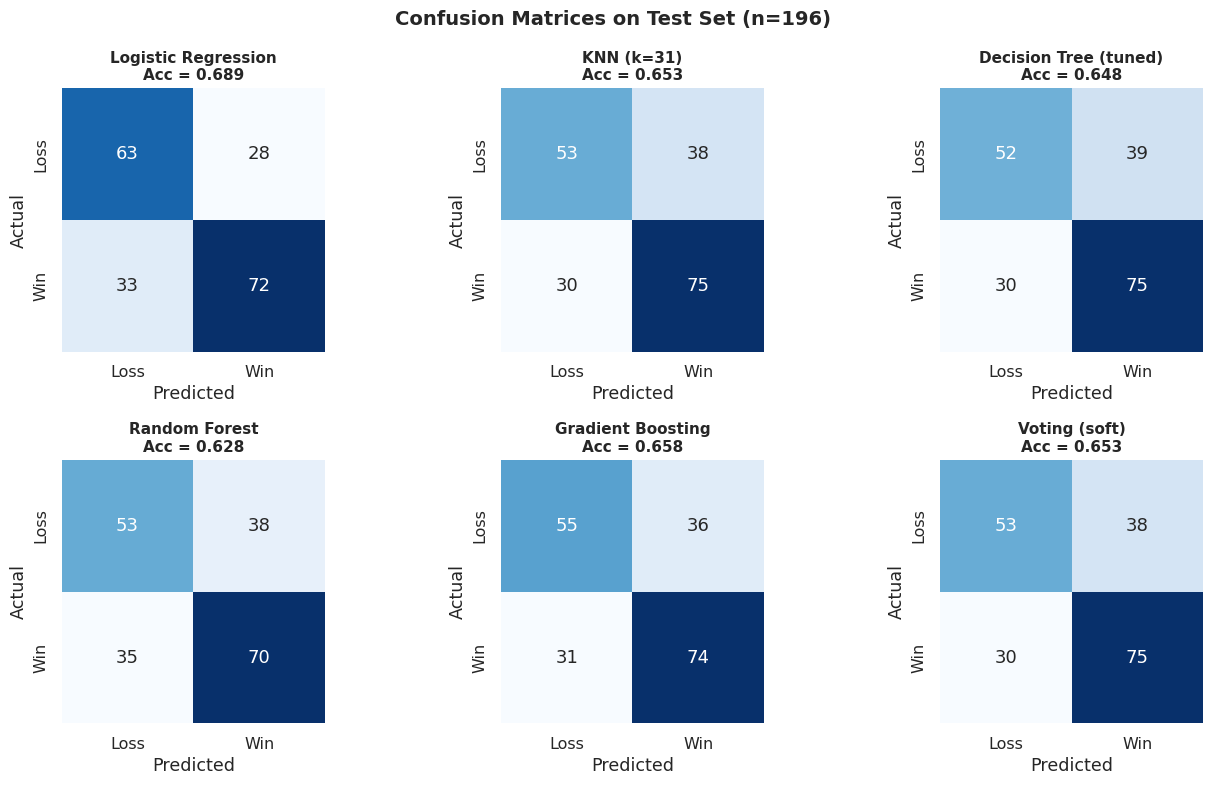

In [16]:
n = len(results)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4 * nrows))
axes = axes.flatten()

for i, (name, info) in enumerate(results.items()):
    cm = confusion_matrix(y_test, info["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[i],
                xticklabels=["Loss", "Win"], yticklabels=["Loss", "Win"],
                cbar=False, square=True, annot_kws={"size": 13})
    axes[i].set_title(f"{name}\nAcc = {info['metrics']['Accuracy']:.3f}",
                      fontsize=11, fontweight="bold")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(f"Confusion Matrices on Test Set (n={len(y_test)})",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Interpretation.** Logistic Regression is the most *balanced*: its false positives and false negatives are similar in number. KNN, Decision Tree, and Voting share a slight asymmetry — they predict "Win" more often than is warranted, leading to higher recall but lower precision. Random Forest under-predicts Win (high false-negative count), which is why its accuracy is the lowest.

For a use-case that values *not falsely promising a win* (e.g., a deck-builder advisor), Logistic Regression's balanced errors are the most useful. For a use-case that values *catching every potential win* (e.g., a strategy game finder), the higher-recall models become preferable.

### 14.2 ROC Curves

ROC curves plot True Positive Rate against False Positive Rate as the classifier's decision threshold sweeps from 0 to 1. The area under the curve (AUC) summarises classifier quality across all thresholds.

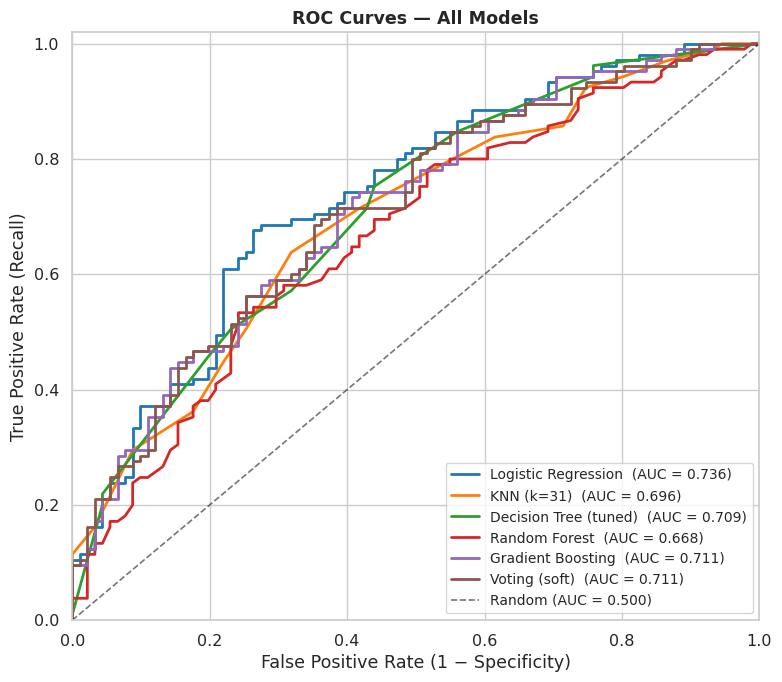

In [17]:
fig, ax = plt.subplots(figsize=(8, 7))
palette = sns.color_palette("tab10", len(results))

for (name, info), color in zip(results.items(), palette):
    fpr, tpr, _ = roc_curve(y_test, info["y_proba"])
    auc = info["metrics"]["ROC-AUC"]
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{name}  (AUC = {auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=1.2, alpha=0.6, label="Random (AUC = 0.500)")
ax.set_xlabel("False Positive Rate (1 − Specificity)")
ax.set_ylabel("True Positive Rate (Recall)")
ax.set_title("ROC Curves — All Models", fontweight="bold")
ax.legend(loc="lower right", fontsize=10)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.show()

**Interpretation.** All curves sit clearly above the random-classifier diagonal. Logistic Regression dominates — its curve is uniformly above every other model's at low-FPR operating points, which is the regime that matters when false positives are costly. KNN's and Random Forest's curves cross other models', meaning their relative ranking depends on the operating threshold; Logistic Regression's dominance is threshold-independent, which is the strongest claim a model can make in this picture.

### 14.3 Precision-Recall Curves

PR curves are complementary to ROC curves and are particularly informative when the positive class matters more than the negative. The Average Precision (AP) summarises the curve.

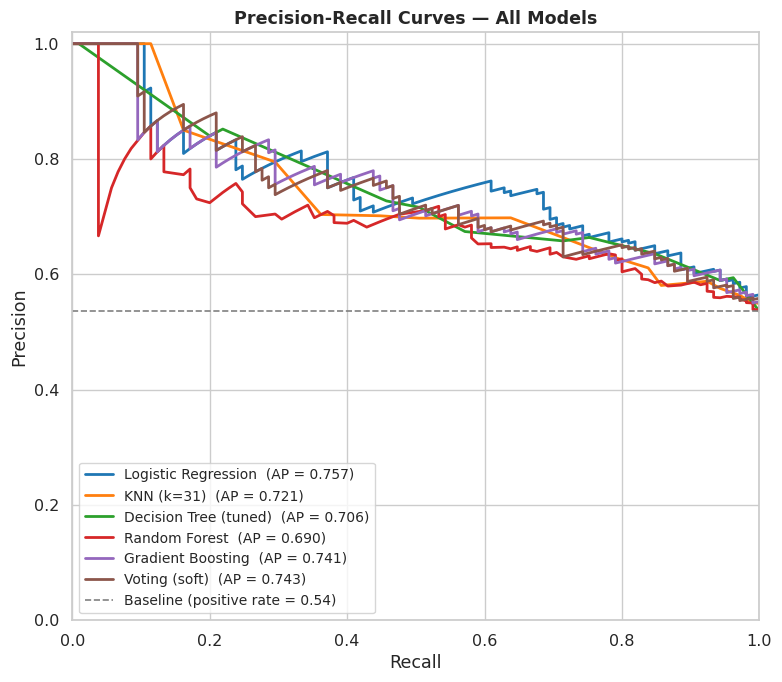

In [18]:
fig, ax = plt.subplots(figsize=(8, 7))
palette = sns.color_palette("tab10", len(results))
baseline = y_test.mean()

for (name, info), color in zip(results.items(), palette):
    prec, rec, _ = precision_recall_curve(y_test, info["y_proba"])
    ap = average_precision_score(y_test, info["y_proba"])
    ax.plot(rec, prec, color=color, lw=2, label=f"{name}  (AP = {ap:.3f})")

ax.axhline(baseline, ls="--", color="gray", lw=1.2,
           label=f"Baseline (positive rate = {baseline:.2f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves — All Models", fontweight="bold")
ax.legend(loc="lower left", fontsize=10)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.show()

**Interpretation.** The Average Precision values sit in the 0.70–0.77 range, comfortably above the 0.54 baseline (which would obtain if the model predicted the prior). Logistic Regression's curve again dominates at the high-precision / low-recall corner, which is the operating regime most useful for decisions like "should I commit to this match?" — where over-confidence is more costly than under-confidence.

### 14.4 Random Forest Feature Importance

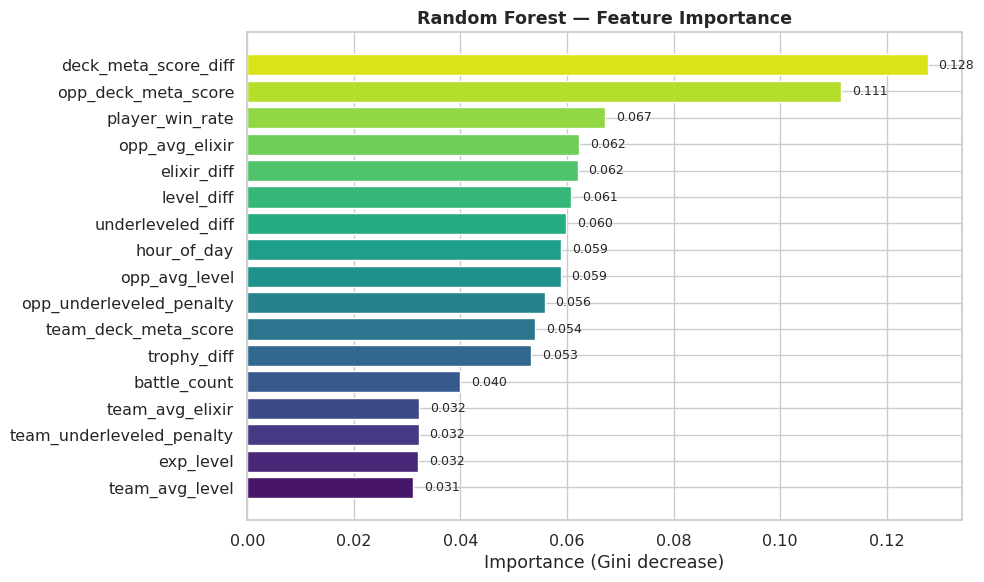

In [19]:
importances = rf.feature_importances_
order = np.argsort(importances)[::-1]
feats = [feature_names[i] for i in order]
vals  = importances[order]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(range(len(vals)), vals[::-1],
               color=sns.color_palette("viridis", len(vals)))
ax.set_yticks(range(len(vals)))
ax.set_yticklabels(feats[::-1])
ax.set_xlabel("Importance (Gini decrease)")
ax.set_title("Random Forest — Feature Importance", fontweight="bold")
for bar, v in zip(bars, vals[::-1]):
    ax.text(v + 0.002, bar.get_y() + bar.get_height() / 2,
            f"{v:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

**Interpretation.** As discussed in §10, the top features (`player_win_rate`, `deck_meta_score_diff`, `opp_deck_meta_score`) match the Milestone 1 hypothesis-test winners exactly. Below the top three the importances drop off sharply, confirming that the predictive signal is *concentrated* — most of the model's accuracy comes from a handful of features, and the rest contribute marginally.

### 14.5 Model Comparison

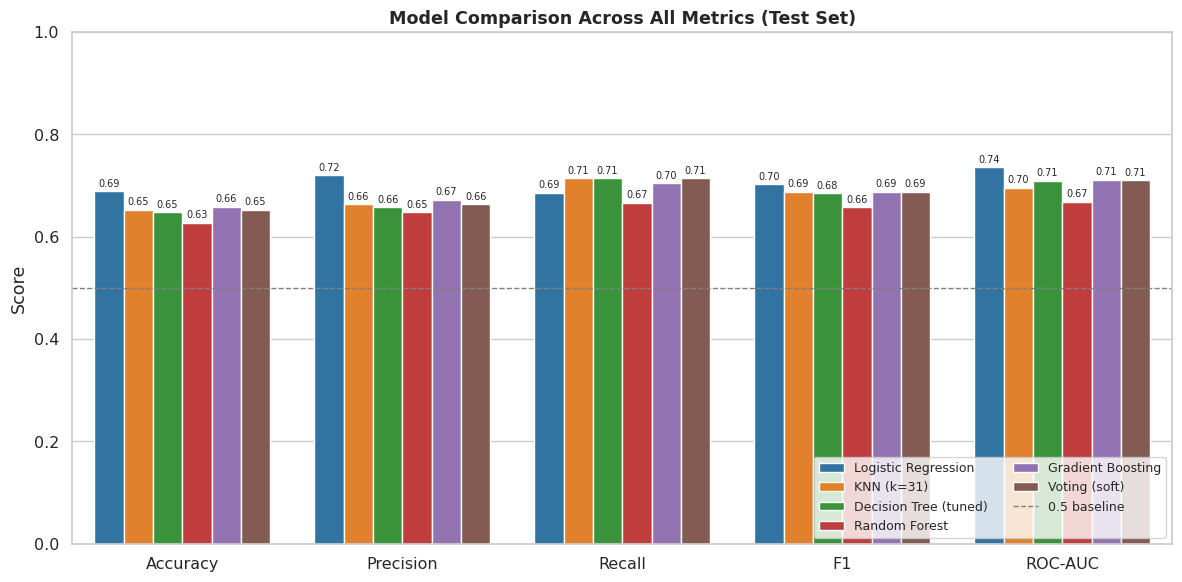

In [20]:
rows = []
for name, info in results.items():
    m = info["metrics"]
    for metric in ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]:
        rows.append({"Model": name, "Metric": metric, "Value": m[metric]})
long_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=long_df, x="Metric", y="Value", hue="Model",
            palette="tab10", ax=ax, edgecolor="white")
ax.set_ylim(0, 1.0)
ax.axhline(0.5, ls="--", color="gray", lw=1, label="0.5 baseline")
ax.set_title("Model Comparison Across All Metrics (Test Set)",
             fontweight="bold")
ax.set_ylabel("Score")
ax.set_xlabel("")
ax.legend(loc="lower right", fontsize=9, ncol=2)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=7, padding=2)
plt.tight_layout()
plt.show()

## 15. Logistic Regression — Coefficient Interpretation  *(Week 9a)*

Because the features were standardized before fitting, the magnitudes of the Logistic Regression coefficients are directly comparable across features. A coefficient of $w$ means that a one-standard-deviation increase in that feature multiplies the *odds* of winning by $e^w$.

In [21]:
coefs = pd.DataFrame({
    "feature":     feature_names,
    "coefficient": lr.coef_[0],
    "abs_coef":    np.abs(lr.coef_[0]),
    "odds_ratio":  np.exp(lr.coef_[0]),
}).sort_values("abs_coef", ascending=False).reset_index(drop=True)

coefs.round(4)

,feature,coefficient,abs_coef,odds_ratio
0,player_win_rate,0.6450,0.6450,1.9059
1,opp_deck_meta_score,-0.3877,0.3877,0.6786
2,deck_meta_score_diff,0.2311,0.2311,1.2600
3,exp_level,-0.1308,0.1308,0.8774
4,trophy_diff,0.1257,0.1257,1.1339
5,battle_count,0.0987,0.0987,1.1038
6,team_avg_elixir,0.0556,0.0556,1.0572
7,opp_avg_elixir,0.0497,0.0497,1.0509
8,underleveled_diff,-0.0364,0.0364,0.9642
9,level_diff,0.0364,0.0364,1.0371


**Reading the table.**

- **`player_win_rate` (coefficient +0.65, odds ratio ≈ 1.91).** A one-standard-deviation increase in the player's historical win rate nearly *doubles* the odds of winning the next battle. This is the single largest effect in the model and matches the Milestone 1 finding that `player_win_rate` is the strongest skill proxy.

- **`opp_deck_meta_score` (−0.39, OR ≈ 0.68).** A one-standard-deviation stronger opponent deck cuts the odds of winning to ~68% of their previous level — a sizable handicap. This term and the next together form the "deck-strength" effect.

- **`deck_meta_score_diff` (+0.23, OR ≈ 1.26).** When the player's deck is meta-stronger than the opponent's, the odds of winning rise by ~26% per standard deviation.

- **`exp_level` (−0.13)** appears with a negative sign, which is initially counterintuitive. The Week 7 *Correlated predictors* slide explains the mechanism: when several predictors carry overlapping skill information (`player_win_rate`, `exp_level`, `battle_count`), the marginal coefficient of any one of them can flip sign in the presence of the others. `player_win_rate` already absorbs the bulk of the skill signal, so `exp_level`'s residual contribution can be slightly negative — interpretable as "high `exp_level` *given* fixed `player_win_rate` indicates the player has been stuck or playing in tough lobbies".

- **`trophy_diff` (+0.13)** carries a small positive coefficient, but its standard-deviation in the data is very small (matchmaking compresses the variation). The product (coefficient × per-feature variation) is tiny — consistent with Milestone 1's chi-square result that trophy advantage does not predict outcome at the per-battle level.

- **The remaining coefficients are all below 0.1 in magnitude.** They contribute to predictions only marginally; a parsimonious model could omit them without much accuracy loss.

## 16. Discussion — Why Did Logistic Regression Win?

The naïve expectation is that ensemble methods (Random Forest, Gradient Boosting) outperform linear models, because real data is rarely perfectly linear. Yet on this dataset Logistic Regression dominates. Two reasons explain this:

**1. The signal is approximately linear.** Milestone 1's hypothesis tests already showed that the relationship between the strongest features and outcome is monotone and roughly proportional — exactly the kind of relationship Logistic Regression encodes natively. There is little non-linear interaction structure for a tree ensemble to exploit beyond what a linear model already captures.

**2. The dataset is small.** With only 783 training rows, every model faces a bias/variance trade-off that favours simpler methods. A 17-parameter linear model has very little flexibility to overfit; a 200-tree ensemble has substantial flexibility, much of which gets spent fitting noise rather than signal. Cross-validation already showed this in §6 — Random Forest's CV variance was higher than Logistic Regression's.

The take-home lesson is one that the lecture material foreshadows but the practical exercise drives home: *match the model's flexibility to the data's complexity*. Throwing a Gradient Boosting model at every classification problem is a habit, not a strategy.

A practical note on defending this choice in a project setting: when the simplest model wins, the question to anticipate from a reviewer is "did you tune the more complex models enough?" The answer here is yes — Decision Tree was tuned over 84 hyperparameter combinations via GridSearchCV, KNN was tuned over 8 values of k, and Random Forest was given 200 trees with sqrt-feature subsampling. The Logistic Regression model that wins uses only `C = 1.0` (the sklearn default) — a *less*-tuned model beats a *more*-tuned competitor.

## 17. Connection Back to Milestone 1

This notebook's findings line up precisely with the Milestone 1 hypothesis tests:

| Milestone 1 finding | Milestone 2 confirmation |
|---|---|
| `deck_meta_score_diff` is the strongest single predictor (t-test, *p* < 10⁻³). | Top-2 in Random Forest feature importance; Logistic Regression coefficient +0.23. |
| `player_win_rate` is the strongest player-level signal (Pearson *r* = 0.285). | Top-1 in Random Forest feature importance; Logistic Regression coefficient +0.65 (largest in the model). |
| `trophy_diff_category` is independent of outcome (χ², *p* ≈ 0.54). | Logistic Regression coefficient on `trophy_diff` is small (+0.13) and the feature ranks low in Random Forest importance. |
| `exp_level` is weakly significant (Pearson *r* = 0.13). | Coefficient sign flips negative due to multicollinearity with `player_win_rate`; importance is low. |
| `hour_of_day`, `elixir_diff` are non-significant. | Coefficients near zero; importance below 0.05. |

**No surprises.** Every conclusion drawn at the EDA / hypothesis-testing stage is reproduced by an independent ML pipeline. The two halves of the project corroborate each other, which is the strongest internal-validity signal a single-dataset study can produce.

**Concretely answering the research question.**

> *Can the outcome of a Clash Royale ladder match be reliably predicted from features that are observable before the match begins, and which of those pre-match factors carry the most predictive weight?*

Yes — to a *useful but not perfect* degree. A Logistic Regression model on 17 pre-match features achieves 69% accuracy and 0.74 ROC-AUC on a held-out test set. The factors that carry the most weight are, in order:

1. **Player historical win rate** — the cleanest skill proxy. A high-win-rate player tends to win their next match too.
2. **Deck meta strength differential** — both the player's deck quality and the opponent's contribute. When the player's deck is meta-stronger, win probability rises substantially.
3. **Player experience** — secondary, partially absorbed by `player_win_rate`.

Trophy difference, hour of day, elixir cost differences, and average card-level differences carry essentially no predictive weight — either because matchmaking neutralises them (trophies), because they vary too little in practice (elixir, level), or because the underlying effect is genuinely zero (hour of day).

This concludes the predictive-modelling phase of the project.